# Minimal PPO Self-Play for Chess960

This notebook is intentionally small and educational. It trains a tiny PPO policy/value model on Chess960 self-play using:

- `python-chess` for Chess960 legality, castling, and game termination
- a fixed from-square/to-square/promotion action vocabulary
- legal action masking before sampling
- sparse terminal win/draw/loss rewards
- optional dense reward shaping from a simple board-quality score
- evaluation against fixed random and material bots

The important diagnostic idea: **self-play win/loss is not a reliable progress signal by itself**, because both sides are controlled by the same evolving policy. Watch fixed-opponent evaluation and board-score trends instead.

In [1]:
# If needed in a fresh notebook:
# %pip install python-chess torch numpy matplotlib

import random
import time
from dataclasses import dataclass
from collections import Counter

import chess
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

## Configuration

The defaults are deliberately small so the notebook starts producing logs quickly. Increase `self_play_games_per_iter`, `eval_games`, and `total_iterations` once the pipeline looks healthy.

In [2]:
@dataclass
class Config:
    seed: int = 7
    total_iterations: int = 200
    self_play_games_per_iter: int = 12
    max_plies: int = 160

    gamma: float = 0.99
    learning_rate: float = 3e-3
    ppo_epochs: int = 3
    minibatch_size: int = 256
    clip_eps: float = 0.2
    value_coef: float = 0.5
    entropy_coef: float = 0.02
    max_grad_norm: float = 0.5

    # Board-score shaping. Keep this small: terminal result is still the main objective.
    shaping_coef: float = 0.01
    speed_ply_penalty: float = 0.001
    terminal_speed_coef: float = 0.05

    eval_every: int = 2
    eval_games: int = 24

cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(cfg.seed)
print("device:", device)

device: cpu


## Move/action encoding

Action space:

`from_square * 64 * 5 + to_square * 5 + promotion_index`

Promotion index:

- `0`: no promotion
- `1`: knight
- `2`: bishop
- `3`: rook
- `4`: queen

In [3]:
PROMO_TO_IDX = {
    None: 0,
    chess.KNIGHT: 1,
    chess.BISHOP: 2,
    chess.ROOK: 3,
    chess.QUEEN: 4,
}
IDX_TO_PROMO = {v: k for k, v in PROMO_TO_IDX.items()}
ACTION_SIZE = 64 * 64 * 5

def move_to_action(move: chess.Move) -> int:
    promo_idx = PROMO_TO_IDX.get(move.promotion, 0)
    return ((move.from_square * 64) + move.to_square) * 5 + promo_idx

def action_to_move(action: int) -> chess.Move:
    promo_idx = action % 5
    x = action // 5
    to_square = x % 64
    from_square = x // 64
    promotion = IDX_TO_PROMO[promo_idx]
    return chess.Move(from_square, to_square, promotion=promotion)

def legal_action_mask(board: chess.Board) -> np.ndarray:
    mask = np.zeros(ACTION_SIZE, dtype=np.bool_)
    for move in board.legal_moves:
        mask[move_to_action(move)] = True
    return mask

## Chess960 helpers

In [4]:
def board_from_chess960_id(spid: int) -> chess.Board:
    try:
        board = chess.Board.from_chess960_pos(spid)
    except AttributeError:
        board = chess.Board(chess960=True)
        board.set_chess960_pos(spid)
    board.chess960 = True
    return board

def new_random_chess960_board(rng: np.random.Generator):
    spid = int(rng.integers(0, 960))
    return board_from_chess960_id(spid), spid

def terminal_winner(board: chess.Board):
    outcome = board.outcome(claim_draw=True)
    if outcome is None:
        return None
    return outcome.winner

## Board-quality score

`board_score(board, ply_count=None, perspective=None)` returns a score from `perspective`'s point of view.

If `perspective=None`, it uses the current side to move. During reward shaping we pass the **acting player** explicitly, so the before/after scores stay in the same perspective even though the turn changes after a move.

The score is intentionally hackable:

```text
board_score = material_score + position_score + speed_score
```

- `material_score`: standard material values
- `position_score`: small center-control, development, castling-rights, and check terms
- `speed_score`: tiny per-ply penalty, so better positions reached earlier score slightly higher

In [5]:
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.0,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0,
}
CENTER_SQUARES = [chess.D4, chess.E4, chess.D5, chess.E5]
MINOR_PIECES = {chess.KNIGHT, chess.BISHOP}

def _material_score_white(board: chess.Board) -> float:
    score = 0.0
    for piece in board.piece_map().values():
        value = PIECE_VALUES[piece.piece_type]
        score += value if piece.color == chess.WHITE else -value
    return score

def _position_score_white(board: chess.Board) -> float:
    # Tiny center-control term: count attackers on the four central squares.
    center = 0.0
    for square in CENTER_SQUARES:
        center += 0.03 * len(board.attackers(chess.WHITE, square))
        center -= 0.03 * len(board.attackers(chess.BLACK, square))

    # Tiny development term: minor pieces that have left their home rank.
    development = 0.0
    for square, piece in board.piece_map().items():
        if piece.piece_type not in MINOR_PIECES:
            continue
        rank = chess.square_rank(square)
        if piece.color == chess.WHITE and rank != 0:
            development += 0.04
        elif piece.color == chess.BLACK and rank != 7:
            development -= 0.04

    # Small proxy for king safety. In Chess960, castling rights can still matter early.
    safety = 0.0
    if board.has_castling_rights(chess.WHITE):
        safety += 0.05
    if board.has_castling_rights(chess.BLACK):
        safety -= 0.05

    # Penalize the side currently in check.
    check = 0.0
    if board.is_check():
        check = -0.25 if board.turn == chess.WHITE else 0.25

    return center + development + safety + check

def board_score_components(board: chess.Board, ply_count=None, perspective=None):
    """Return board-quality components from the requested perspective.

    Perspective convention:
    - positive is good for `perspective`
    - if `perspective` is omitted, use `board.turn`
    - speed is not color-flipped; it is a small universal preference for earlier progress
    """
    if perspective is None:
        perspective = board.turn

    sign = 1.0 if perspective == chess.WHITE else -1.0
    material = sign * _material_score_white(board)
    position = sign * _position_score_white(board)
    speed = -cfg.speed_ply_penalty * float(ply_count or 0)
    total = material + position + speed

    return {
        "material": float(material),
        "position": float(position),
        "speed": float(speed),
        "total": float(total),
    }

def board_score(board: chess.Board, ply_count=None, perspective=None) -> float:
    return board_score_components(board, ply_count=ply_count, perspective=perspective)["total"]

def terminal_reward_for_player(winner, player, ply_count, max_plies):
    """Sparse terminal result from one stored state's player perspective."""
    if winner is None:
        return 0.0

    base = 1.0 if winner == player else -1.0
    speed_bonus = max(0.0, (max_plies - ply_count) / max_plies) * cfg.terminal_speed_coef
    return base * (1.0 + speed_bonus)

## Board tensor encoding

Shape: `(15, 8, 8)`

- 12 piece planes
- 1 side-to-move plane
- 1 white castling-right rook-square plane
- 1 black castling-right rook-square plane

In [6]:
PIECE_TO_PLANE = {
    (chess.WHITE, chess.PAWN): 0,
    (chess.WHITE, chess.KNIGHT): 1,
    (chess.WHITE, chess.BISHOP): 2,
    (chess.WHITE, chess.ROOK): 3,
    (chess.WHITE, chess.QUEEN): 4,
    (chess.WHITE, chess.KING): 5,
    (chess.BLACK, chess.PAWN): 6,
    (chess.BLACK, chess.KNIGHT): 7,
    (chess.BLACK, chess.BISHOP): 8,
    (chess.BLACK, chess.ROOK): 9,
    (chess.BLACK, chess.QUEEN): 10,
    (chess.BLACK, chess.KING): 11,
}
N_PLANES = 15

def square_to_rc(square):
    file = chess.square_file(square)
    rank = chess.square_rank(square)
    return 7 - rank, file

def encode_board(board: chess.Board) -> np.ndarray:
    x = np.zeros((N_PLANES, 8, 8), dtype=np.float32)

    for square, piece in board.piece_map().items():
        plane = PIECE_TO_PLANE[(piece.color, piece.piece_type)]
        r, c = square_to_rc(square)
        x[plane, r, c] = 1.0

    x[12, :, :] = 1.0 if board.turn == chess.WHITE else 0.0

    for square in chess.SQUARES:
        if board.castling_rights & chess.BB_SQUARES[square]:
            piece = board.piece_at(square)
            if piece and piece.piece_type == chess.ROOK:
                r, c = square_to_rc(square)
                if piece.color == chess.WHITE:
                    x[13, r, c] = 1.0
                else:
                    x[14, r, c] = 1.0

    return x

## Small policy/value network

In [7]:
class SmallPolicyValueNet(nn.Module):
    def __init__(self, action_size=ACTION_SIZE):
        super().__init__()
        self.conv1 = nn.Conv2d(N_PLANES, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.fc = nn.Linear(64 * 8 * 8, 256)
        self.policy = nn.Linear(256, action_size)
        self.value = nn.Linear(256, 1)

    def forward(self, obs):
        x = F.relu(self.conv1(obs))
        x = F.relu(self.conv2(x))
        x = x.flatten(1)
        x = F.relu(self.fc(x))
        logits = self.policy(x)
        value = torch.tanh(self.value(x)).squeeze(-1)
        return logits, value

def masked_distribution(logits, legal_mask):
    masked_logits = logits.masked_fill(~legal_mask, -1e9)
    return Categorical(logits=masked_logits)

model = SmallPolicyValueNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
print("parameters:", sum(p.numel() for p in model.parameters()))

parameters: 6358081


## Correctness smoke checks

In [8]:
def verify_chess960_castling_smoke():
    for spid in range(960):
        board = board_from_chess960_id(spid)

        # Remove non-king/rook pieces so python-chess can expose legal Chess960 castling.
        for square, piece in list(board.piece_map().items()):
            if piece.piece_type not in (chess.KING, chess.ROOK):
                board.remove_piece_at(square)

        board.turn = chess.WHITE
        castles = [m for m in board.legal_moves if board.is_castling(m)]
        if castles:
            print("Chess960 castling smoke OK:", "spid", spid, "castles", [board.uci(m) for m in castles[:4]])
            return

    raise AssertionError("Could not find a Chess960 castling smoke position.")

def sanity_checks():
    rng = np.random.default_rng(cfg.seed)
    board, spid = new_random_chess960_board(rng)

    print("sample Chess960 id:", spid)
    print("sample FEN:", board.fen())

    mask = legal_action_mask(board)
    assert mask.any(), "Initial position should have legal moves."

    examples = list(board.legal_moves)[:8]
    print("example legal moves:")
    for move in examples:
        aid = move_to_action(move)
        decoded = action_to_move(aid)
        print(" ", board.uci(move), "->", aid, "->", decoded.uci())
        assert decoded == move

    comps = board_score_components(board, ply_count=0, perspective=board.turn)
    print("initial board_score components:", comps)

    verify_chess960_castling_smoke()

sanity_checks()

sample Chess960 id: 907
sample FEN: rkqrbnnb/pppppppp/8/8/8/8/PPPPPPPP/RKQRBNNB w KQkq - 0 1
example legal moves:
  g1h3 -> 2035 -> g1h3
  g1f3 -> 2025 -> g1f3
  f1g3 -> 1710 -> f1g3
  f1e3 -> 1700 -> f1e3
  h2h3 -> 4915 -> h2h3
  g2g3 -> 4590 -> g2g3
  f2f3 -> 4265 -> f2f3
  e2e3 -> 3940 -> e2e3
initial board_score components: {'material': 0.0, 'position': 0.0, 'speed': -0.0, 'total': 0.0}
Chess960 castling smoke OK: spid 2 castles ['g1h1']


## Self-play rollout collection with board-score shaping

For each stored state/action:

```text
current_score = board_score(board_before_move, perspective=acting_player)
next_score    = board_score(board_after_move,  perspective=acting_player)
shaping       = shaping_coef * (next_score - current_score)
return        = discounted_terminal_result + shaping
```

This keeps the terminal result dominant while adding a small dense signal for material/position/speed changes.

In [9]:
def select_action_for_training(board):
    obs = torch.tensor(encode_board(board), dtype=torch.float32, device=device).unsqueeze(0)
    mask_np = legal_action_mask(board)
    assert mask_np.any(), "No legal actions in non-terminal state."

    legal_mask = torch.tensor(mask_np, dtype=torch.bool, device=device).unsqueeze(0)

    with torch.no_grad():
        logits, value = model(obs)
        dist = masked_distribution(logits, legal_mask)
        action = dist.sample()
        log_prob = dist.log_prob(action)

    move = action_to_move(int(action.item()))
    assert move in board.legal_moves, f"Sampled illegal move: {move.uci()}"

    return {
        "obs": obs.squeeze(0).cpu().numpy(),
        "mask": mask_np,
        "action": int(action.item()),
        "log_prob": float(log_prob.item()),
        "value": float(value.item()),
        "player": board.turn,
        "move": move,
    }

def collect_self_play_rollouts(num_games, max_plies, gamma):
    rng = np.random.default_rng(random.randrange(1_000_000_000))

    all_steps = []
    game_lengths = []
    results = Counter()
    final_scores_white = []
    score_improvements_white = []

    for _ in range(num_games):
        board, spid = new_random_chess960_board(rng)
        start_score_white = board_score(board, ply_count=0, perspective=chess.WHITE)
        game_steps = []

        for ply in range(max_plies):
            if board.is_game_over(claim_draw=True):
                break

            actor = board.turn
            score_before = board_score_components(board, ply_count=ply, perspective=actor)
            step = select_action_for_training(board)

            board.push(step["move"])

            score_after = board_score_components(board, ply_count=ply + 1, perspective=actor)
            shaping_reward = cfg.shaping_coef * (score_after["total"] - score_before["total"])

            step["score_before"] = score_before
            step["score_after"] = score_after
            step["shaping_reward"] = float(shaping_reward)
            game_steps.append(step)

        truncated = not board.is_game_over(claim_draw=True)
        winner = None if truncated else terminal_winner(board)

        if winner == chess.WHITE:
            results["white_win"] += 1
        elif winner == chess.BLACK:
            results["black_win"] += 1
        else:
            results["draw_or_trunc"] += 1

        T = len(game_steps)
        game_lengths.append(T)

        final_score_white = board_score(board, ply_count=T, perspective=chess.WHITE)
        final_scores_white.append(final_score_white)
        score_improvements_white.append(final_score_white - start_score_white)

        for i, step in enumerate(game_steps):
            terminal_reward = terminal_reward_for_player(winner, step["player"], T, max_plies)
            discounted_terminal = terminal_reward * (gamma ** (T - 1 - i))
            total_return = discounted_terminal + step["shaping_reward"]

            step["terminal_reward"] = float(terminal_reward)
            step["return"] = float(total_return)
            step["avg_reward_for_log"] = float(total_return)

        all_steps.extend(game_steps)

    if not all_steps:
        raise RuntimeError("No rollout steps collected. Try increasing max_plies or games.")

    batch = {
        "obs": np.stack([s["obs"] for s in all_steps]),
        "mask": np.stack([s["mask"] for s in all_steps]),
        "action": np.array([s["action"] for s in all_steps], dtype=np.int64),
        "old_log_prob": np.array([s["log_prob"] for s in all_steps], dtype=np.float32),
        "value": np.array([s["value"] for s in all_steps], dtype=np.float32),
        "return": np.array([s["return"] for s in all_steps], dtype=np.float32),
    }

    state_scores = [s["score_before"]["total"] for s in all_steps]
    material_scores = [s["score_before"]["material"] for s in all_steps]
    position_scores = [s["score_before"]["position"] for s in all_steps]
    shaped_rewards = [s["shaping_reward"] for s in all_steps]
    total_returns = [s["return"] for s in all_steps]

    stats = {
        "games": num_games,
        "positions": len(all_steps),
        "avg_game_len": float(np.mean(game_lengths)),
        "results": dict(results),
        "avg_board_score": float(np.mean(state_scores)),
        "avg_material_score": float(np.mean(material_scores)),
        "avg_position_score": float(np.mean(position_scores)),
        "avg_final_board_score": float(np.mean(final_scores_white)),
        "avg_board_score_improvement": float(np.mean(score_improvements_white)),
        "avg_shaped_reward": float(np.mean(shaped_rewards)),
        "avg_training_return": float(np.mean(total_returns)),
    }

    return batch, stats

## PPO update

In [10]:
def ppo_update(batch):
    obs = torch.tensor(batch["obs"], dtype=torch.float32, device=device)
    masks = torch.tensor(batch["mask"], dtype=torch.bool, device=device)
    actions = torch.tensor(batch["action"], dtype=torch.long, device=device)
    old_log_probs = torch.tensor(batch["old_log_prob"], dtype=torch.float32, device=device)
    returns = torch.tensor(batch["return"], dtype=torch.float32, device=device)

    with torch.no_grad():
        old_values = torch.tensor(batch["value"], dtype=torch.float32, device=device)
        advantages = returns - old_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    n = obs.shape[0]
    metrics = Counter()
    updates = 0

    for _ in range(cfg.ppo_epochs):
        indices = torch.randperm(n, device=device)

        for start in range(0, n, cfg.minibatch_size):
            mb = indices[start:start + cfg.minibatch_size]

            logits, values = model(obs[mb])
            dist = masked_distribution(logits, masks[mb])

            new_log_probs = dist.log_prob(actions[mb])
            entropy = dist.entropy().mean()

            log_ratio = new_log_probs - old_log_probs[mb]
            ratio = torch.exp(log_ratio)

            unclipped = ratio * advantages[mb]
            clipped = torch.clamp(ratio, 1 - cfg.clip_eps, 1 + cfg.clip_eps) * advantages[mb]
            policy_loss = -torch.min(unclipped, clipped).mean()

            value_loss = F.mse_loss(values, returns[mb])
            loss = policy_loss + cfg.value_coef * value_loss - cfg.entropy_coef * entropy

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            optimizer.step()

            with torch.no_grad():
                approx_kl = ((torch.exp(log_ratio) - 1) - log_ratio).mean()
                clip_frac = ((ratio - 1.0).abs() > cfg.clip_eps).float().mean()

            metrics["policy_loss"] += float(policy_loss.item())
            metrics["value_loss"] += float(value_loss.item())
            metrics["entropy"] += float(entropy.item())
            metrics["approx_kl"] += float(approx_kl.item())
            metrics["clip_frac"] += float(clip_frac.item())
            updates += 1

    return {k: v / updates for k, v in metrics.items()}

## Fixed-opponent evaluation

Evaluation reports board score from the PPO agent's perspective, not just White's perspective. This is more useful than self-play W/L because the opponents are fixed.

In [11]:
@torch.no_grad()
def select_model_move(board, deterministic=True):
    obs = torch.tensor(encode_board(board), dtype=torch.float32, device=device).unsqueeze(0)
    mask_np = legal_action_mask(board)
    assert mask_np.any(), "No legal moves available."

    legal_mask = torch.tensor(mask_np, dtype=torch.bool, device=device).unsqueeze(0)
    logits, value = model(obs)
    masked_logits = logits.masked_fill(~legal_mask, -1e9)

    if deterministic:
        action = int(torch.argmax(masked_logits, dim=-1).item())
    else:
        dist = Categorical(logits=masked_logits)
        action = int(dist.sample().item())

    move = action_to_move(action)
    assert move in board.legal_moves, f"Model selected illegal eval move: {move.uci()}"
    return move

def random_bot_move(board, rng=None):
    legal = list(board.legal_moves)
    assert legal, "Random bot called with no legal moves."
    if rng is None:
        return random.choice(legal)
    return legal[int(rng.integers(0, len(legal)))]

def material_bot_move(board, rng=None):
    """One-ply material bot. It chooses the move with best material after the move."""
    legal = list(board.legal_moves)
    assert legal, "Material bot called with no legal moves."
    actor = board.turn

    best_score = -1e9
    best_moves = []
    for move in legal:
        child = board.copy(stack=False)
        child.push(move)
        score = board_score_components(child, ply_count=board.ply() + 1, perspective=actor)["material"]
        if score > best_score + 1e-9:
            best_score = score
            best_moves = [move]
        elif abs(score - best_score) <= 1e-9:
            best_moves.append(move)

    if rng is None:
        return random.choice(best_moves)
    return best_moves[int(rng.integers(0, len(best_moves)))]

def evaluate_vs_bot(bot_move_fn, bot_name, num_games=24, max_plies=160, seed_offset=10_000):
    rng = np.random.default_rng(cfg.seed + seed_offset)
    model.eval()

    score = 0.0
    counts = Counter()
    lengths = []
    final_totals = []
    final_materials = []
    final_positions = []

    for game_idx in range(num_games):
        board, spid = new_random_chess960_board(rng)
        agent_color = chess.WHITE if game_idx % 2 == 0 else chess.BLACK

        for ply in range(max_plies):
            if board.is_game_over(claim_draw=True):
                break

            if board.turn == agent_color:
                move = select_model_move(board, deterministic=True)
            else:
                move = bot_move_fn(board, rng)

            assert move in board.legal_moves
            board.push(move)

        winner = None if not board.is_game_over(claim_draw=True) else terminal_winner(board)
        lengths.append(board.ply())

        comps = board_score_components(board, ply_count=board.ply(), perspective=agent_color)
        final_totals.append(comps["total"])
        final_materials.append(comps["material"])
        final_positions.append(comps["position"])

        if winner is None:
            counts["draw"] += 1
            score += 0.5
        elif winner == agent_color:
            counts["win"] += 1
            score += 1.0
        else:
            counts["loss"] += 1

    model.train()

    return {
        f"{bot_name}_wins": counts["win"],
        f"{bot_name}_draws": counts["draw"],
        f"{bot_name}_losses": counts["loss"],
        f"{bot_name}_win_rate": counts["win"] / num_games,
        f"{bot_name}_draw_rate": counts["draw"] / num_games,
        f"{bot_name}_loss_rate": counts["loss"] / num_games,
        f"{bot_name}_score_pct": score / num_games,
        f"{bot_name}_avg_final_board_score": float(np.mean(final_totals)),
        f"{bot_name}_avg_material_score": float(np.mean(final_materials)),
        f"{bot_name}_avg_position_score": float(np.mean(final_positions)),
        f"{bot_name}_avg_game_length": float(np.mean(lengths)),
    }

def format_eval_line(name, stats):
    return (
        f"{name}: score={stats[f'{name}_score_pct']:.3f} "
        f"win={stats[f'{name}_win_rate']:.3f} "
        f"draw={stats[f'{name}_draw_rate']:.3f} "
        f"loss={stats[f'{name}_loss_rate']:.3f} "
        f"board={stats[f'{name}_avg_final_board_score']:.3f} "
        f"mat={stats[f'{name}_avg_material_score']:.3f} "
        f"pos={stats[f'{name}_avg_position_score']:.3f} "
        f"len={stats[f'{name}_avg_game_length']:.1f}"
    )

## Training loop

Read the logs like this:

- Self-play W/L says who won between two copies of the same evolving agent. It is useful for debugging termination, not for claiming progress.
- `avg_board`, `avg_final_board`, and `avg_improve` are dense board-quality diagnostics.
- Fixed-opponent `random_*` and `material_*` metrics are the main progress indicators.

In [12]:
history = []

for iteration in range(1, cfg.total_iterations + 1):
    t0 = time.time()

    batch, rollout_stats = collect_self_play_rollouts(
        num_games=cfg.self_play_games_per_iter,
        max_plies=cfg.max_plies,
        gamma=cfg.gamma,
    )

    update_stats = ppo_update(batch)

    eval_stats = {}
    if iteration % cfg.eval_every == 0 or iteration == 1:
        eval_stats.update(evaluate_vs_bot(random_bot_move, "random", cfg.eval_games, cfg.max_plies, seed_offset=20_000 + iteration))
        eval_stats.update(evaluate_vs_bot(material_bot_move, "material", cfg.eval_games, cfg.max_plies, seed_offset=30_000 + iteration))

    elapsed = time.time() - t0

    row = {
        "iteration": iteration,
        **rollout_stats,
        **update_stats,
        **eval_stats,
        "elapsed": elapsed,
    }
    history.append(row)

    print(
        f"iter={iteration:03d} "
        f"games={rollout_stats['games']} "
        f"positions={rollout_stats['positions']} "
        f"avg_len={rollout_stats['avg_game_len']:.1f} "
        f"selfplay={rollout_stats['results']} "
        f"avg_board={rollout_stats['avg_board_score']:.3f} "
        f"avg_mat={rollout_stats['avg_material_score']:.3f} "
        f"avg_pos={rollout_stats['avg_position_score']:.3f} "
        f"avg_final_board={rollout_stats['avg_final_board_score']:.3f} "
        f"avg_improve={rollout_stats['avg_board_score_improvement']:.3f} "
        f"avg_shaped={rollout_stats['avg_shaped_reward']:.4f} "
        f"avg_return={rollout_stats['avg_training_return']:.3f} "
        f"policy_loss={update_stats['policy_loss']:.4f} "
        f"value_loss={update_stats['value_loss']:.4f} "
        f"entropy={update_stats['entropy']:.3f} "
        f"kl={update_stats['approx_kl']:.5f} "
        f"clip={update_stats['clip_frac']:.3f} "
        f"time={elapsed:.1f}s"
    )

    if eval_stats:
        print("  eval", format_eval_line("random", eval_stats))
        print("  eval", format_eval_line("material", eval_stats))

iter=001 games=12 positions=1881 avg_len=156.8 selfplay={'draw_or_trunc': 10, 'black_win': 1, 'white_win': 1} avg_board=-0.276 avg_mat=-0.182 avg_pos=-0.016 avg_final_board=0.566 avg_improve=0.566 avg_shaped=0.0040 avg_return=0.005 policy_loss=-0.0386 value_loss=0.0587 entropy=3.158 kl=0.09222 clip=0.427 time=10.7s
  eval random: score=0.438 win=0.000 draw=0.875 loss=0.125 board=2.593 mat=2.792 pos=-0.102 len=96.4
  eval material: score=0.417 win=0.000 draw=0.833 loss=0.167 board=-24.653 mat=-24.292 pos=-0.228 len=133.5
iter=002 games=12 positions=1850 avg_len=154.2 selfplay={'draw_or_trunc': 11, 'black_win': 1} avg_board=-0.307 avg_mat=-0.212 avg_pos=-0.016 avg_final_board=4.337 avg_improve=4.337 avg_shaped=0.0043 avg_return=0.004 policy_loss=-0.0420 value_loss=0.0188 entropy=3.090 kl=0.03788 clip=0.360 time=11.0s
  eval random: score=0.479 win=0.000 draw=0.958 loss=0.042 board=0.165 mat=0.375 pos=-0.076 len=134.3
  eval material: score=0.417 win=0.000 draw=0.833 loss=0.167 board=-24.

## Plot progress

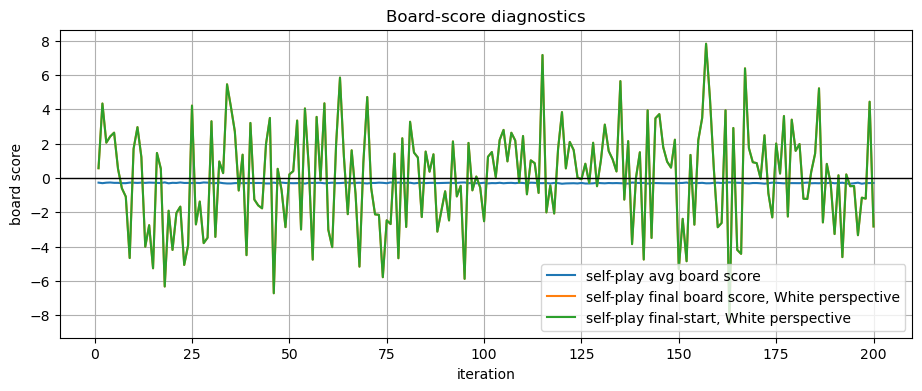

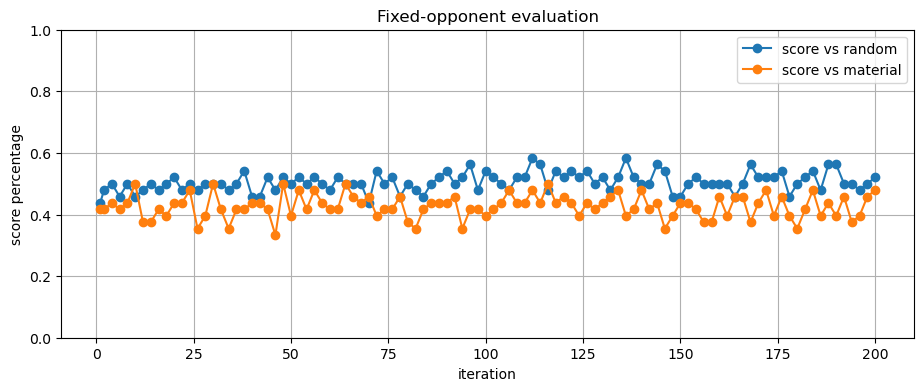

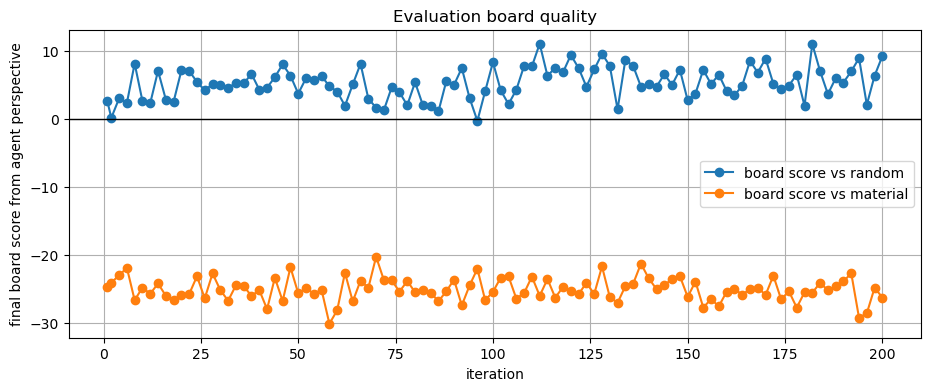

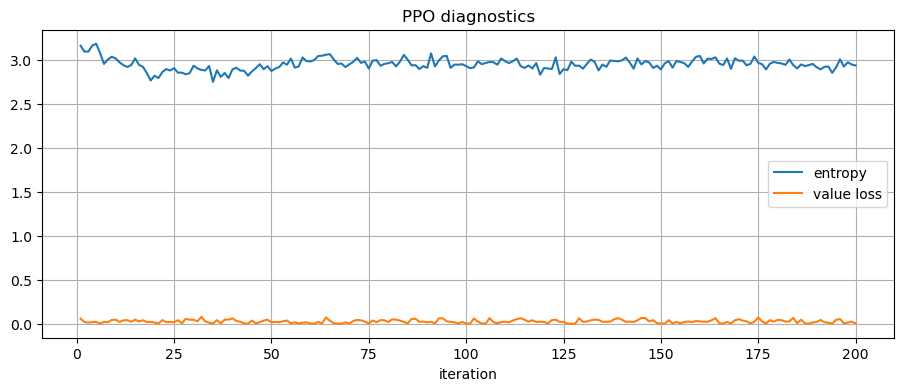

In [13]:
if plt is not None and history:
    xs = [h["iteration"] for h in history]

    plt.figure(figsize=(11, 4))
    plt.plot(xs, [h["avg_board_score"] for h in history], label="self-play avg board score")
    plt.plot(xs, [h["avg_final_board_score"] for h in history], label="self-play final board score, White perspective")
    plt.plot(xs, [h["avg_board_score_improvement"] for h in history], label="self-play final-start, White perspective")
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("iteration")
    plt.ylabel("board score")
    plt.title("Board-score diagnostics")
    plt.legend()
    plt.grid(True)
    plt.show()

    eval_x = [h["iteration"] for h in history if "random_score_pct" in h]
    if eval_x:
        plt.figure(figsize=(11, 4))
        plt.plot(eval_x, [h["random_score_pct"] for h in history if "random_score_pct" in h], marker="o", label="score vs random")
        plt.plot(eval_x, [h["material_score_pct"] for h in history if "material_score_pct" in h], marker="o", label="score vs material")
        plt.ylim(0, 1)
        plt.xlabel("iteration")
        plt.ylabel("score percentage")
        plt.title("Fixed-opponent evaluation")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(11, 4))
        plt.plot(eval_x, [h["random_avg_final_board_score"] for h in history if "random_avg_final_board_score" in h], marker="o", label="board score vs random")
        plt.plot(eval_x, [h["material_avg_final_board_score"] for h in history if "material_avg_final_board_score" in h], marker="o", label="board score vs material")
        plt.axhline(0, color="black", linewidth=1)
        plt.xlabel("iteration")
        plt.ylabel("final board score from agent perspective")
        plt.title("Evaluation board quality")
        plt.legend()
        plt.grid(True)
        plt.show()

    plt.figure(figsize=(11, 4))
    plt.plot(xs, [h["entropy"] for h in history], label="entropy")
    plt.plot(xs, [h["value_loss"] for h in history], label="value loss")
    plt.xlabel("iteration")
    plt.title("PPO diagnostics")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("matplotlib not available or history empty; skipping plots.")

## Notes and next experiments

This notebook is still intentionally minimal. The board score is a diagnostic and a tiny shaping signal; it should not be mistaken for the true chess objective.

If learning is flat:

- increase fixed-opponent evaluation games before drawing conclusions
- try training against random before pure self-play
- increase `self_play_games_per_iter`
- lower `shaping_coef` if the agent chases material while ignoring mate
- add GAE after the Monte Carlo version is understood
- keep watching illegal-move assertions; they should never fire